In [20]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
import pandas as pd

data = {
    "Age": [22, 25, 47, 52, 46, 56, 30],
    "Income": [15000, 30000, 120000, 110000, 80000, 150000, 40000],
    "Purchased": [0, 0, 1, 1, 1, 1, 0]
}

df = pd.DataFrame(data)

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Age        7 non-null      int64
 1   Income     7 non-null      int64
 2   Purchased  7 non-null      int64
dtypes: int64(3)
memory usage: 300.0 bytes


,0
Age,0
Income,0
Purchased,0


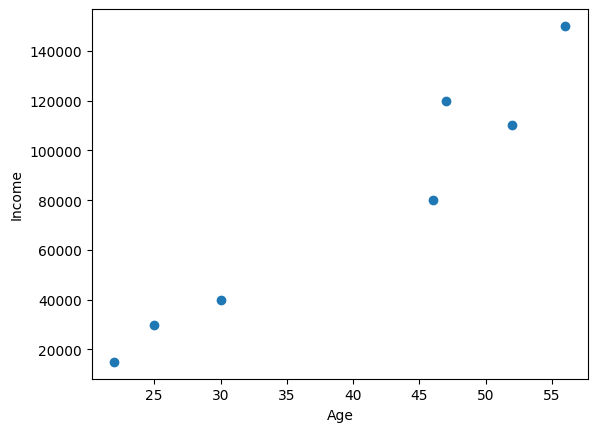

In [13]:
# Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
plt.scatter(df["Age"], df["Income"])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()


In [14]:
#Feature Engineering
X = df[["Age", "Income"]]
y = df["Purchased"]

# Feature Scaling (important for ML models)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# Training model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [16]:
#✔ Evaluates how well model performs on unseen data
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [17]:
# Hyperparameter Tuning
# Finds best regularization strength
# Improves model performance
from sklearn.model_selection import GridSearchCV
params = { "C": [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameter:", grid.best_params_)

Best Parameter: {'C': 0.01}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 12.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args,

In [18]:
# Deployment & Save model
import joblib

joblib.dump(model, "purchase_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [21]:
# Load & Predict (Deployment Simulation)
model = joblib.load("purchase_model.pkl")
scaler = joblib.load("scaler.pkl")

new_customer = [[35, 60000]]
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)
print("Purchased?" , prediction)

# Output -  Purchased? [1]

# In real life → Flask / FastAPI / Cloud
# Monitoring → accuracy drift, data drift


Purchased? [1]
